In [50]:
import pandas as pd
import numpy as np
from unidecode import unidecode 
import re
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv(r"C:\Users\Abcom\Downloads\ArchiveDataSet\SampleSuperstore.csv")

In [52]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [53]:
df.shape

(9994, 13)

In [54]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [56]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(17)

In [58]:
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

In [59]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [60]:
df[df.duplicated()]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
3406,Standard Class,Home Office,United States,Columbus,Ohio,43229,East,Furniture,Chairs,281.372,2,0.3,-12.0588
3670,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
4117,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
4553,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
5905,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
6146,Standard Class,Corporate,United States,San Francisco,California,94122,West,Office Supplies,Art,11.760,4,0.0,3.1752
6334,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864
6357,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
7608,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416


In [61]:
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
6409,First Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Paper,47.952,3,0.2,16.1838
8032,First Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Paper,47.952,3,0.2,16.1838
5493,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
5905,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
2807,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
8095,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
8457,Second Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,3.564,3,0.8,-6.2370
9477,Second Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,3.564,3,0.8,-6.2370
8533,Standard Class,Consumer,United States,Detroit,Michigan,48227,Central,Furniture,Chairs,389.970,3,0.0,35.0973
9262,Standard Class,Consumer,United States,Detroit,Michigan,48227,Central,Furniture,Chairs,389.970,3,0.0,35.0973


In [62]:
df = df.drop_duplicates()

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [65]:
df.boxplot(column=['Sales', 'Profit'])

<Axes: >

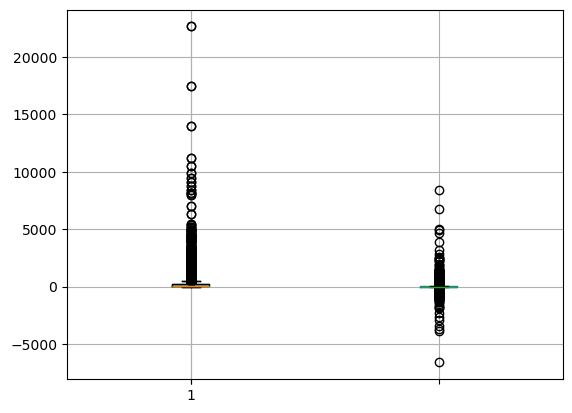

In [66]:
plt.boxplot(df['Sales'])
plt.show()

In [67]:
df['Category'].value_counts()

Category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

In [68]:
df['Region'].value_counts()

Region
West       3193
East       2845
Central    2319
South      1620
Name: count, dtype: int64

In [69]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        1522
Paper          1359
Furnishings     956
Phones          889
Storage         846
Art             795
Accessories     775
Chairs          615
Appliances      466
Labels          363
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [70]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [71]:
df['Sub-Category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

In [72]:
df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [73]:
df.describe(include='object')

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,9977,9977,9977,9977,9977,9977,9977,9977
unique,4,3,1,531,49,4,3,17
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Binders
freq,5955,5183,9977,914,1996,3193,6012,1522


In [74]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [75]:
profile = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Numeric Columns": df.select_dtypes(include=['int64','float64']).shape[1],
    "Categorical Columns": df.select_dtypes(include=['object']).shape[1]
}

profile

{'Rows': 9977,
 'Columns': 13,
 'Missing Values': np.int64(0),
 'Duplicate Rows': np.int64(0),
 'Numeric Columns': 5,
 'Categorical Columns': 8}

In [76]:
df['Postal Code'] = df['Postal Code'].astype(str)

In [77]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code      object
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [78]:
profile = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Numeric Columns": df.select_dtypes(include=['int64','float64']).shape[1],
    "Categorical Columns": df.select_dtypes(include=['object']).shape[1]
}

profile

{'Rows': 9977,
 'Columns': 13,
 'Missing Values': np.int64(0),
 'Duplicate Rows': np.int64(0),
 'Numeric Columns': 4,
 'Categorical Columns': 9}

In [79]:
df[['Sales', 'Profit', 'Quantity', 'Discount']].corr()

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479067,0.200722,-0.028311
Profit,0.479067,1.000000,0.066211,-0.219662
Quantity,0.200722,0.066211,1.000000,0.008678
Discount,-0.028311,-0.219662,0.008678,1.000000


In [80]:
print("Total Sales:", df['Sales'].sum())

Total Sales: 2296195.5903


In [81]:
Total_Sales = df['Sales'].sum() 

In [82]:
Total_Sales

np.float64(2296195.5903)

In [83]:
print("Total Profit:", df['Profit'].sum())


Total Profit: 286241.42260000005


In [84]:
print("Total Quantity:", df['Quantity'].sum())


Total Quantity: 37820


In [85]:
print("Average Discount:", df['Discount'].mean())

Average Discount: 0.15627844041294978


In [86]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64

In [87]:
df.groupby('Region')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Region,,
West,725255.6365,108329.8079
East,678435.1960,91506.3092
Central,500782.8528,39655.8752
South,391721.9050,46749.4303


In [88]:
region_summary = df.groupby('Region')[['Sales','Profit']].sum()

region_summary['Profit Margin %'] = (
    region_summary['Profit'] / region_summary['Sales']
) * 100

region_summary.sort_values(by='Profit Margin %', ascending=False)

,Sales,Profit,Profit Margin %
Region,,,
West,725255.6365,108329.8079,14.936776
East,678435.1960,91506.3092,13.487848
South,391721.9050,46749.4303,11.934342
Central,500782.8528,39655.8752,7.918777


In [89]:
df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741306.3133,18421.8137
Office Supplies,718735.2440,122364.6608


In [90]:
df.groupby('Sub-Category')[['Sales','Profit']].sum().sort_values(by='Profit', ascending=False)

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78224.1420,33944.2395
Binders,203409.1690,30228.0003
Chairs,327777.7610,26567.1278
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91683.0240,13052.7230


In [91]:
df[df['Sub-Category'] == 'Tables'].describe()

,Sales,Quantity,Discount,Profit
count,319.000000,319.000000,319.000000,319.000000
mean,648.794771,3.890282,0.261285,-55.565771
std,615.774655,2.446381,0.169622,230.565006
min,24.368000,1.000000,0.000000,-1862.312400
25%,244.006000,2.000000,0.200000,-122.829300
50%,447.840000,3.000000,0.300000,-31.372200
75%,872.170000,5.000000,0.400000,33.851700
max,4297.644000,13.000000,0.500000,629.010000


In [92]:
df[df['Sub-Category'] == 'Tables'][['Sales','Profit','Discount']].head(10)

,Sales,Profit,Discount
3,957.5775,-383.0310,0.45
10,1706.1840,85.3092,0.20
24,1044.6300,240.2649,0.00
117,787.5300,165.3813,0.00
125,617.7000,-407.6820,0.50
201,218.7500,-161.8750,0.50
226,622.4500,136.9390,0.00
231,233.8600,-102.0480,0.45
232,620.6145,-248.2458,0.45
241,177.2250,-120.5130,0.50


In [93]:
tables = df[df['Sub-Category'] == 'Tables'][['Category','Sub-Category','Sales', 'Profit', 'Discount',]].copy()

tables['Profit %'] = (tables['Profit'] / tables['Sales']) * 100



In [94]:
tables

,Category,Sub-Category,Sales,Profit,Discount,Profit %
3,Furniture,Tables,957.5775,-383.0310,0.45,-40.000000
10,Furniture,Tables,1706.1840,85.3092,0.20,5.000000
24,Furniture,Tables,1044.6300,240.2649,0.00,23.000000
117,Furniture,Tables,787.5300,165.3813,0.00,21.000000
125,Furniture,Tables,617.7000,-407.6820,0.50,-66.000000
...,...,...,...,...,...,...
9857,Furniture,Tables,3393.6800,610.8624,0.00,18.000000
9899,Furniture,Tables,330.5880,-143.2548,0.40,-43.333333
9937,Furniture,Tables,71.0880,-1.7772,0.20,-2.500000
9955,Furniture,Tables,273.5680,10.2588,0.20,3.750000


In [95]:
df.groupby('Sub-Category')[['Discount']].mean().sort_values(by='Discount', ascending=False)

,Discount
Sub-Category,
Binders,0.372011
Machines,0.306087
Tables,0.261285
Bookcases,0.211140
Chairs,0.170244
Appliances,0.166524
Copiers,0.161765
Phones,0.154556
Furnishings,0.138494


In [96]:
df.groupby('Sub-Category')[['Sales', 'Profit', 'Discount']].agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).sort_values(by='Profit')

,Sales,Profit,Discount
Sub-Category,,,
Tables,206965.5320,-17725.4811,0.261285
Bookcases,114879.9963,-3472.5560,0.211140
Supplies,46673.5380,-1189.0995,0.076842
Fasteners,3024.2800,949.5182,0.082028
Machines,189238.6310,3384.7569,0.306087
Labels,12444.9120,5526.3820,0.068871
Art,27107.0320,6524.6118,0.074969
Envelopes,16476.4020,6964.1767,0.080315
Furnishings,91683.0240,13052.7230,0.138494


In [97]:
df.groupby('State')[['Sales', 'Profit']].sum().sort_values(by='Profit')

,Sales,Profit
State,,
Texas,170124.5418,-25750.9833
Ohio,77976.7640,-16959.3178
Pennsylvania,116496.3620,-15565.4035
Illinois,80162.5370,-12601.6500
North Carolina,55603.1640,-7490.9122
Colorado,32108.1180,-6527.8579
Tennessee,30661.8730,-5341.6936
Arizona,35282.0010,-3427.9246
Florida,89473.7080,-3399.3017


In [99]:
df.groupby('City')[['Sales', 'Profit']].sum().sort_values(by='Profit').head(20)

,Sales,Profit
City,,
Philadelphia,109061.4610,-13843.2106
Houston,64441.2564,-10175.1755
San Antonio,21843.5280,-7299.0502
Lancaster,9891.4640,-7239.0684
Chicago,48535.9770,-6648.3318
Burlington,21668.0820,-3622.8772
Dallas,20131.9322,-2846.5257
Phoenix,11000.2570,-2790.8832
Aurora,11656.4780,-2691.7386


In [ ]:
Which cities generate the highest losses?------Philadelphia
Are the loss-making cities located in the same loss-making states?-----i am getting any prediction
Are there opportunities to improve performance at the city level?-----not getting prediction i feel some feel needs these kind of explnation

In [100]:
df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

,Sales,Profit
Segment,,
Consumer,1.160833e+06,134007.4413
Corporate,7.060701e+05,91954.9798
Home Office,4.292927e+05,60279.0015


In [ ]:
Which segment generates the highest sales?----consumer
Which segment generates the highest profit?------consumer 
Is the most profitable segment also the highest revenue segment----no we can to say,we should check others factors


In [101]:
df.groupby('Ship Mode')[['Sales', 'Profit']].sum()

,Sales,Profit
Ship Mode,,
First Class,3.513805e+05,48953.6561
Same Day,1.283217e+05,15871.8869
Second Class,4.591770e+05,57446.6516
Standard Class,1.357316e+06,163969.2280


In [102]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()

category_summary['Profit Margin %'] = (
    category_summary['Profit'] /
    category_summary['Sales']
) * 100

category_summary.sort_values(by='Profit Margin %', ascending=False)

,Sales,Profit,Profit Margin %
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,718735.2440,122364.6608,17.024998
Furniture,741306.3133,18421.8137,2.485047


In [103]:
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df.to_csv("Superstore_Cleaned.csv", index=False)

In [106]:
import os

os.getcwd()

'C:\\Users\\Abcom\\DAMP\\datastore'

In [107]:


os.listdir()

['.ipynb_checkpoints', 'datastore.ipynb', 'Superstore_Cleaned.csv']

In [108]:
df.to_excel("Superstore_Cleaned.xlsx", index=False)

In [109]:
os.getcwd()

'C:\\Users\\Abcom\\DAMP\\datastore'